In [8]:
!pip install vedo

Defaulting to user installation because normal site-packages is not writeable


In [9]:
def get_coord(d, value):
    for k in d.key():
        if d[k] == value:
            return k

    return None


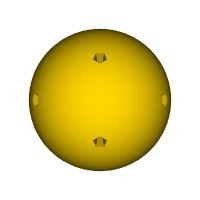

In [10]:
from vedo import Mesh, show

# Load the mesh and optionally a texture
mesh = Mesh("iteracao_4.obj")
# mesh.texture("path/to/your/texture.jpg") # Optional: load texture

# Display the object in an interactive windowmesh)
mesh

In [13]:
import matplotlib.pyplot as plt
import numpy as np


class obj:
    def __init__(self, v = None, f = None , path = None):
        if path:
            self.vdict, self.faces = self.read_obj(path)
        else:
            self.vdict, self.faces = v, f


    def read_obj(self, path):
        V = {}
        F = []
        count = 1
        with open(path, "r") as f:
            for line in f.readlines():
                if line.startswith("v"):
                    V[count] = (float(line.split()[1]), float(line.split()[2]), float(line.split()[3]))
                    count += 1
                elif line.startswith("f"):
                    F.append((
                        int(line.split()[1]),
                        int(line.split()[2]),
                        int(line.split()[3])
                        ))


        return V, F
    
    def improve_obj(self, inplace=False, x=1):

        def normalize(p):
            p = np.array(p)
            return tuple(p / np.linalg.norm(p))

        for _ in range(x):

            edge_cache = {}
            new_faces = []
            new_vertices = dict(self.vdict)

            def get_mid(i, j):

                key = tuple(sorted((i, j)))

                if key in edge_cache:
                    return edge_cache[key]

                mid = (np.array(new_vertices[i]) + np.array(new_vertices[j])) / 2
                p = normalize(mid)

                idx = len(new_vertices) + 1
                new_vertices[idx] = p
                edge_cache[key] = idx

                return idx

            for a, b, c in self.faces:

                m1 = get_mid(a, b)
                m2 = get_mid(b, c)
                m3 = get_mid(c, a)

                f1 = (a, m1, m3)
                f2 = (b, m2, m1)
                f3 = (c, m3, m2)
                f4 = (m1, m2, m3)

                new_faces += [f1, f2, f3, f4]

            

            if not inplace:
                return obj(self.vdict, self.faces)
            
            else:
                self.vdict = new_vertices
                self.faces = new_faces

    def orient_faces(self):

        for i,(a,b,c) in enumerate(self.faces):

            va = np.array(self.vdict[a])
            vb = np.array(self.vdict[b])
            vc = np.array(self.vdict[c])

            n = np.cross(vb-va, vc-va)

            if np.dot(n, va) < 0:
                self.faces[i] = (a,c,b)
        

def write(path, ob):
    with open(path, "w") as fr:

        for v in ob.vdict.keys():
            fr.write(f"v {ob.vdict[v][0]} {ob.vdict[v][1]} {ob.vdict[v][2]}\n")

        for face in ob.faces:
            fr.write(f"f {face[0]} {face[1]} {face[2]} \n")

ico = obj(path = "ico.obj")
        

ico.vdict
ico.improve_obj(inplace = True, x = 5)
ico.vdict

write("zz.obj", ico)


In [ ]:
ico.orient_faces()

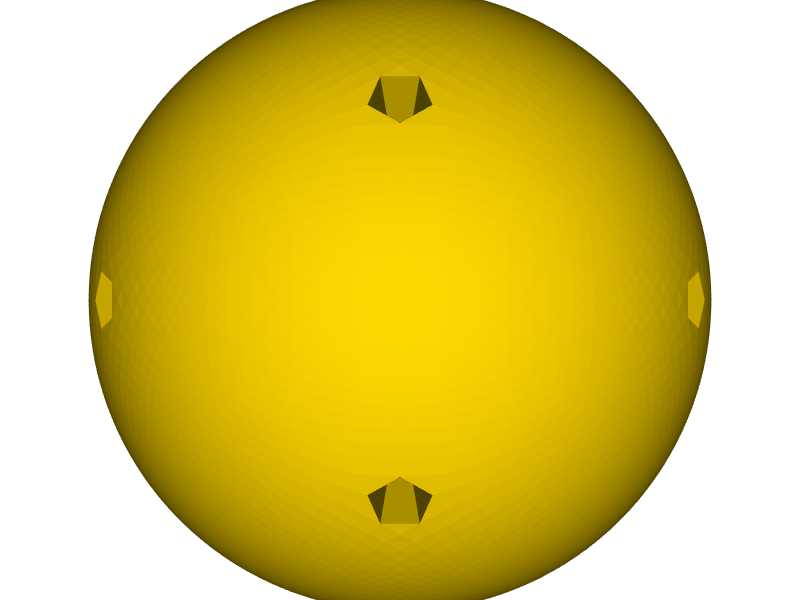

In [15]:
from vedo import Mesh, show
mesh = Mesh("zz.obj")


show(mesh)

Número de Vértices: 10485762
Número de Faces:    20971520


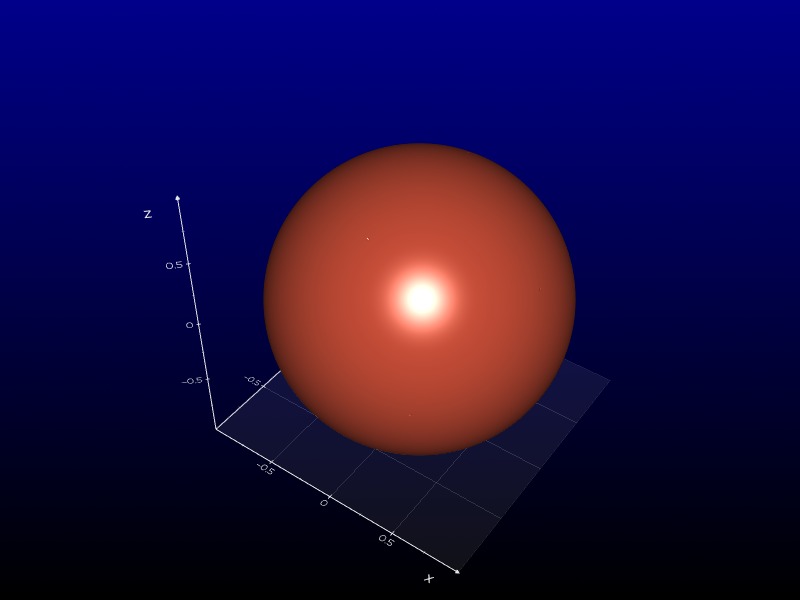

In [ ]:
# 1. Cor e Acabamento
mesh.c("tomato")        # Cor (pode usar hex codes ou nomes)
mesh.lighting("glossy") # 'glossy', 'plastic', 'metallic', 'default'

# 2. Suavização (Opcional)
# Como são triângulos planos, a esfera pode parecer facetada. 
# compute_normals() ajuda a luz a bater suavemente.
mesh.compute_normals() 

# 3. Informações no console
print(f"Número de Vértices: {mesh.npoints}")
print(f"Número de Faces:    {mesh.ncells}")

# --- Visualização ---
show(
    mesh, 
    bg="black",       # Fundo preto destaca melhor o 3D
    bg2="darkblue",   # Gradiente de fundo
    axes=1,           # Mostra eixos
    viewup="z",       # Define Z como 'para cima'
    interactive=True
)

In [ ]:
!pip install open3d

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 15.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 66.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, 

In [ ]:
import open3d as o3d
import numpy as np


# 1. Extract coordinates from your icosahedron object
# We use a list comprehension for cleaner, faster code
points = np.array(
    [
        v.coord
        for v in improve_obj(
            improve_obj(improve_obj(improve_obj(improve_obj(read_obj("ico.obj")))))
        ).vdict.values()
    ]
)

# 2. Create an Open3D point cloud object
pcd = o3d.geometry.PointCloud()

# Assign the numpy array directly to the Open3D vector
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: color the vertices (e.g., Red) for better visibility
# Creates an array of [1, 0, ac0] of the same length as 'points'
colors = np.tile([1.0, 0.0, 0.0], (len(points), 1))
pcd.colors = o3d.utility.Vector3dVector(colors)

# 3. Visualize
print(f"Visualizing {len(points)} vertices. Press 'q' to close window.")

# Adding a coordinate frame helps to see orientation (Red=X, Green=Y, Blue=Z)
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2, origin=[0, 0, 0])

o3d.visualization.draw_geometries([pcd, axis])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Visualizing 10242 vertices. Press 'q' to close window.


In [ ]:
import open3d as o3d
import numpy as np
import time


# --- Helper to convert your 'obj' class to an Open3D LineSet ---
def obj_to_lineset(my_obj):
    # 1. Vertices
    points = np.array([v.coord for v in my_obj.vdict.values()])

    # 2. Edges (derived from Faces)
    # We use a set to avoid duplicate edges for cleaner rendering
    edges = set()
    for f in my_obj.faces:
        # Convert 1-based index to 0-based
        idx = [i - 1 for i in f]
        # Sort indices to ensure (0,1) is same as (1,0)
        edges.add(tuple(sorted((idx[0], idx[1]))))
        edges.add(tuple(sorted((idx[1], idx[2]))))
        edges.add(tuple(sorted((idx[2], idx[0]))))

    lines_indices = list(edges)

    # 3. Create Open3D Geometry
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(points)
    line_set.lines = o3d.utility.Vector2iVector(lines_indices)

    # Make it Black
    line_set.paint_uniform_color([0, 0, 0])
    return line_set


# --- 1. Pre-calculate the Frames ---
print("Generating frames...")
frames = []
current_obj = read_obj("ico.obj")  # Load your initial icosahedron

# Add the starting shape
frames.append(obj_to_lineset(current_obj))

# Calculate 4 more levels of refinement
for i in range(6):
    current_obj = improve_obj(current_obj)
    frames.append(obj_to_lineset(current_obj))
    print(f"Generated frame {i+1} with {len(current_obj.vdict)} vertices")

# --- 2. Setup the Visualizer ---
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Sphere Refinement Animation", width=800, height=600)

# Add the first frame to initialize the view
current_geometry = frames[0]
vis.add_geometry(current_geometry)

# --- 3. Run the Animation Loop ---
print("Starting animation...")
frame_idx = 0
last_switch_time = time.time()

while True:
    # Check if window is closed
    if not vis.poll_events():
        break

    vis.update_renderer()

    # Switch frames every 1 second
    if time.time() - last_switch_time > 1.0:

        # 1. Remove the old shape (keep camera steady with reset_bounding_box=False)
        vis.remove_geometry(current_geometry, reset_bounding_box=False)

        # 2. Advance to next frame (loop back to 0 if at end)
        frame_idx = (frame_idx + 1) % len(frames)
        current_geometry = frames[frame_idx]

        # 3. Add the new shape
        vis.add_geometry(current_geometry, reset_bounding_box=False)

        print(f"Showing Level {frame_idx}")
        last_switch_time = time.time()

vis.destroy_window()

Generating frames...
Generated frame 1 with 42 vertices
Generated frame 2 with 162 vertices
Generated frame 3 with 642 vertices
Generated frame 4 with 2562 vertices
Generated frame 5 with 10242 vertices
Generated frame 6 with 40962 vertices
Starting animation...
Showing Level 1
Showing Level 2
Showing Level 3
